In [2]:
# ============================================================
# REAL-TIME FRAUD DETECTION SYSTEM WITH EXPLAINABLE AI
# IEEE-CIS Fraud Detection Project
# ============================================================

In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

from sklearn.ensemble import IsolationForest

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import shap
import optuna
import joblib

In [4]:
os.makedirs("charts", exist_ok=True)
os.makedirs("dashboard", exist_ok=True)

In [5]:
transaction_df = pd.read_csv("data/train_transaction.csv")
identity_df = pd.read_csv("data/train_identity.csv")

print("Transaction Shape:", transaction_df.shape)
print("Identity Shape:", identity_df.shape)

Transaction Shape: (590540, 394)
Identity Shape: (144233, 41)


In [6]:
df = transaction_df.merge(
    identity_df,
    on="TransactionID",
    how="left"
)

print("Merged Shape:", df.shape)

Merged Shape: (590540, 434)


In [7]:
print(df.head(10))
print(df.info())

   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   
5        2987005        0          86510            49.0         W   5937   
6        2987006        0          86522           159.0         W  12308   
7        2987007        0          86529           422.5         W  12695   
8        2987008        0          86535            15.0         H   2803   
9        2987009        0          86536           117.0         W  17399   

   card2  card3       card4  card5  ...                id_31  id_32  \
0    NaN  150.0    discover  142.0  ...                  NaN    NaN   
1  404.0  

isFraud
0    569877
1     20663
Name: count, dtype: int64


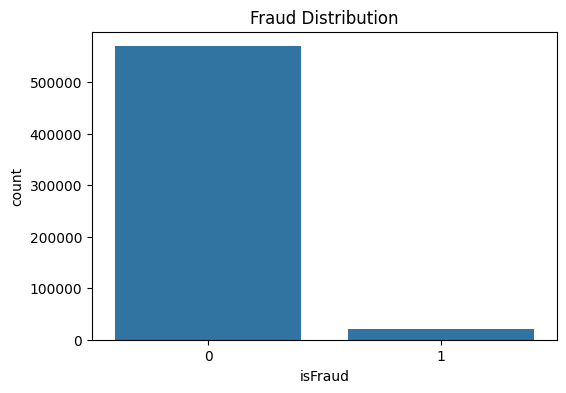

In [8]:
fraud_counts = df["isFraud"].value_counts()

print(fraud_counts)

plt.figure(figsize=(6,4))

sns.countplot(
    x="isFraud",
    data=df
)

plt.title("Fraud Distribution")

plt.savefig(
    "charts/fraud_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [9]:
missing_percent = (
    df.isnull().sum() / len(df)
) * 100

missing_df = pd.DataFrame({
    "Column": missing_percent.index,
    "MissingPercent": missing_percent.values
})

missing_df = missing_df.sort_values(
    by="MissingPercent",
    ascending=False
)

print(missing_df.head(20))

    Column  MissingPercent
417  id_24       99.196159
418  id_25       99.130965
400  id_07       99.127070
401  id_08       99.127070
414  id_21       99.126393
419  id_26       99.125715
420  id_27       99.124699
416  id_23       99.124699
415  id_22       99.124699
14   dist2       93.628374
37      D7       93.409930
411  id_18       92.360721
43     D13       89.509263
44     D14       89.469469
42     D12       89.041047
397  id_04       88.768923
396  id_03       88.768923
36      D6       87.606767
426  id_33       87.589494
402  id_09       87.312290


In [10]:
threshold = 50

cols_to_drop = missing_percent[
    missing_percent > threshold
].index

print("Dropped Columns:", len(cols_to_drop))

df.drop(columns=cols_to_drop, inplace=True)

Dropped Columns: 214


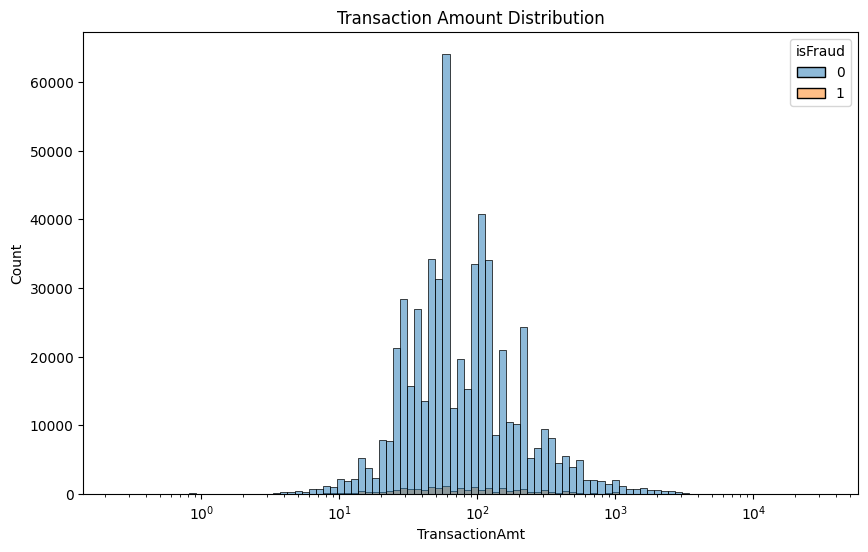

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="TransactionAmt",
    hue="isFraud",
    bins=100,
    log_scale=True
)

plt.title("Transaction Amount Distribution")

plt.savefig(
    "charts/transaction_amount_distribution.png",
    bbox_inches="tight"
)

plt.show()

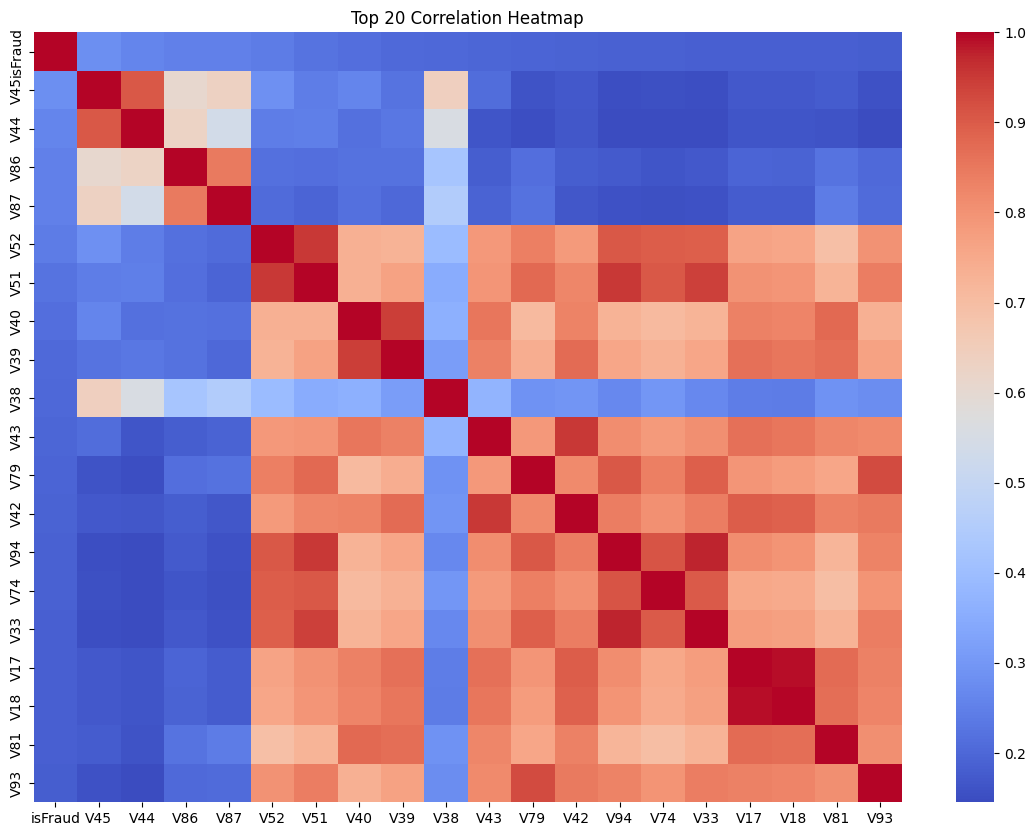

In [12]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

corr_target = (
    df[numeric_cols]
    .corr()["isFraud"]
    .abs()
    .sort_values(ascending=False)
)

top20 = corr_target.head(20).index

plt.figure(figsize=(14,10))

sns.heatmap(
    df[top20].corr(),
    cmap="coolwarm"
)

plt.title("Top 20 Correlation Heatmap")

plt.savefig(
    "charts/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

In [13]:
# Amount Ratio

df["AmtToMeanRatio"] = (
    df["TransactionAmt"] /
    df["TransactionAmt"].mean()
)

# Hour Feature

df["HourOfDay"] = (
    (df["TransactionDT"] // 3600) % 24
)

# Device Risk Feature

if "DeviceType" in df.columns:

    df["DeviceRisk"] = np.where(
        df["DeviceType"]
        .astype(str)
        .str.contains("mobile", case=False, na=False),
        1,
        0
    )

else:

    print("DeviceType column not found")

    df["DeviceRisk"] = 0

DeviceType column not found


In [14]:
categorical_cols = df.select_dtypes(
    include="object"
).columns

numerical_cols = df.select_dtypes(
    include=np.number
).columns

print("Categorical Columns:", len(categorical_cols))
print("Numerical Columns:", len(numerical_cols))

Categorical Columns: 9
Numerical Columns: 214


In [15]:
num_imputer = SimpleImputer(
    strategy="median"
)

cat_imputer = SimpleImputer(
    strategy="most_frequent"
)

# Numerical

df[numerical_cols] = num_imputer.fit_transform(
    df[numerical_cols]
)

# Categorical

df[categorical_cols] = cat_imputer.fit_transform(
    df[categorical_cols]
)

In [16]:
label_encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

    label_encoders[col] = le

print("Encoding Completed")

Encoding Completed


In [17]:
X = df.drop("isFraud", axis=1)
y = df["isFraud"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(472432, 222)
(118108, 222)


In [19]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
print("Before SMOTE")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("After SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
isFraud
0.0    455902
1.0     16530
Name: count, dtype: int64
After SMOTE
isFraud
0.0    455902
1.0    455902
Name: count, dtype: int64


In [21]:
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

lgbm_model.fit(
    X_train_smote,
    y_train_smote
)

lgbm_probs = lgbm_model.predict_proba(
    X_test_scaled
)[:,1]

lgbm_preds = (
    lgbm_probs > 0.5
).astype(int)

[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.651685 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 53093
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 218
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [22]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

xgb_probs = xgb_model.predict_proba(
    X_test_scaled
)[:,1]

xgb_preds = (
    xgb_probs > 0.5
).astype(int)

In [23]:
iso_model = IsolationForest(
    contamination=0.035,
    random_state=42
)

iso_model.fit(X_train_scaled)

iso_preds = iso_model.predict(X_test_scaled)

iso_preds = np.where(
    iso_preds == -1,
    1,
    0
)

In [24]:
def evaluate_model(
    y_true,
    y_pred,
    probs=None,
    model_name="Model"
):

    print("="*50)
    print(model_name)
    print("="*50)

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))

    if probs is not None:

        print("ROC-AUC:", roc_auc_score(y_true, probs))

        print(
            "PR-AUC:",
            average_precision_score(y_true, probs)
        )

        # ROC CURVE

        fpr, tpr, _ = roc_curve(y_true, probs)

        plt.figure(figsize=(6,4))

        plt.plot(fpr, tpr)

        plt.title(f"ROC Curve - {model_name}")

        plt.savefig(
            f"charts/{model_name}_roc_curve.png",
            bbox_inches="tight"
        )

        plt.show()

        # PR CURVE

        precision, recall, _ = precision_recall_curve(
            y_true,
            probs
        )

        plt.figure(figsize=(6,4))

        plt.plot(recall, precision)

        plt.title(
            f"Precision Recall Curve - {model_name}"
        )

        plt.savefig(
            f"charts/{model_name}_pr_curve.png",
            bbox_inches="tight"
        )

        plt.show()

    # CONFUSION MATRIX

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.show()

LightGBM
Accuracy: 0.974269312832323
Precision: 0.7252883031301482
Recall: 0.4260827486087588
F1: 0.5368084133516232
ROC-AUC: 0.8939499628151418
PR-AUC: 0.5420442863672881


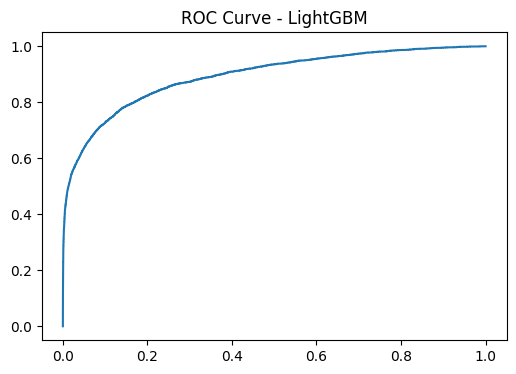

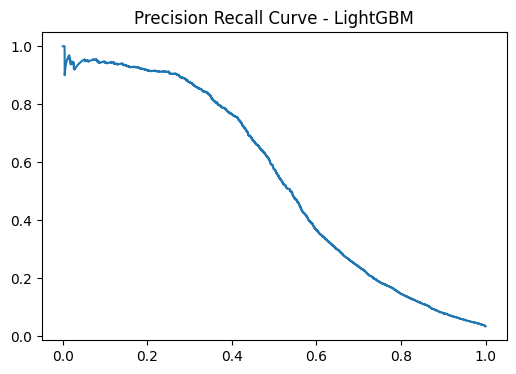

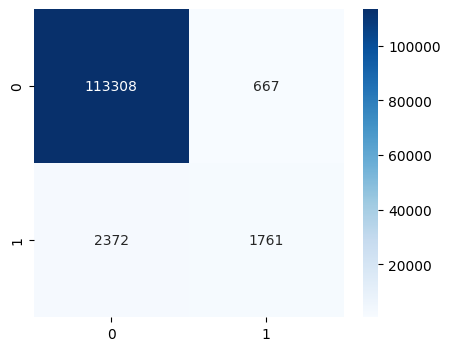

XGBoost
Accuracy: 0.969138415687337
Precision: 0.5689655172413793
Recall: 0.4870554076941689
F1: 0.5248337895971842
ROC-AUC: 0.890666441924671
PR-AUC: 0.5284299557800705


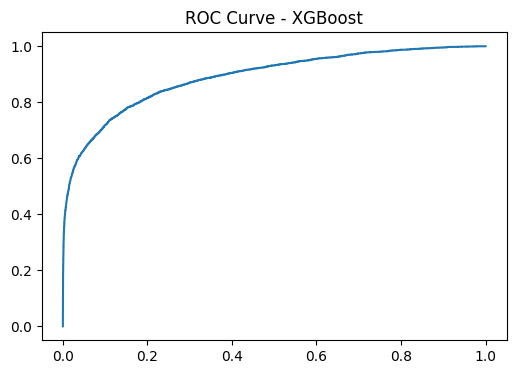

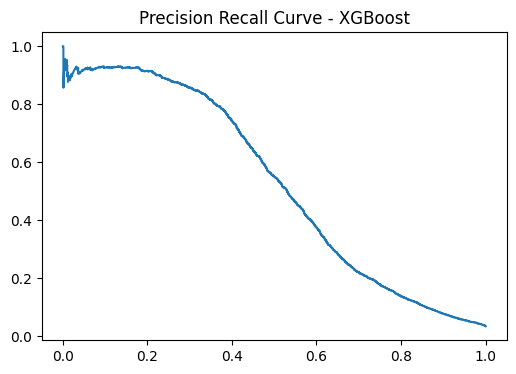

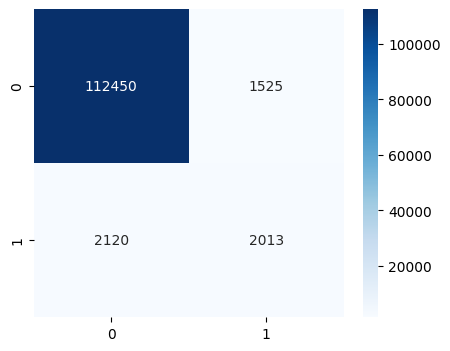

IsolationForest
Accuracy: 0.9411047515832967
Precision: 0.1685841746888941
Recall: 0.17372368739414468
F1: 0.171115347950429


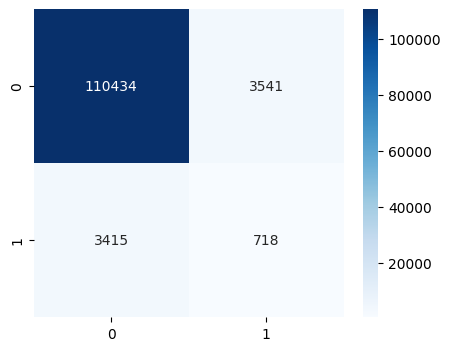

In [25]:
evaluate_model(
    y_test,
    lgbm_preds,
    lgbm_probs,
    "LightGBM"
)


evaluate_model(
    y_test,
    xgb_preds,
    xgb_probs,
    "XGBoost"
)


evaluate_model(
    y_test,
    iso_preds,
    None,
    "IsolationForest"
)

Best Threshold: 0.40000000000000013


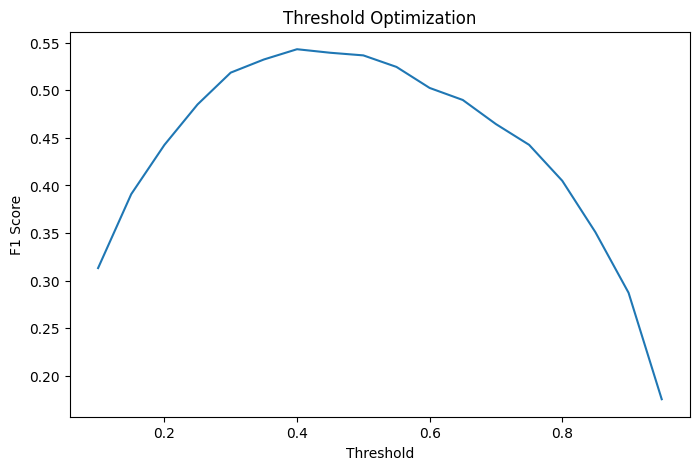

In [26]:
thresholds = np.arange(0.1, 1.0, 0.05)

f1_scores = []

for threshold in thresholds:

    preds = (
        lgbm_probs > threshold
    ).astype(int)

    score = f1_score(y_test, preds)

    f1_scores.append(score)

best_threshold = thresholds[
    np.argmax(f1_scores)
]

print("Best Threshold:", best_threshold)

plt.figure(figsize=(8,5))

plt.plot(thresholds, f1_scores)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")

plt.title("Threshold Optimization")

plt.savefig(
    "charts/threshold_optimization.png",
    bbox_inches="tight"
)

plt.show()

In [27]:
def objective(trial):
    
    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            300
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.2
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            10
        )
    }

    model = LGBMClassifier(**params)

    model.fit(
        X_train_smote,
        y_train_smote
    )

    probs = model.predict_proba(
        X_test_scaled
    )[:,1]

    return roc_auc_score(y_test, probs)

study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=10
)

print(study.best_params)

[I 2026-05-23 22:30:21,241] A new study created in memory with name: no-name-ca77fb51-ae3c-440c-837f-0627645327f7


[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.681887 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 53087
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 218
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[I 2026-05-23 22:31:02,681] Trial 0 finished with value: 0.8774156595247927 and parameters: {'n_estimators': 281, 'learning_rate': 0.018158773509863134, 'max_depth': 6}. Best is trial 0 with value: 0.8774156595247927.


[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.733596 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 53087
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 218
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[I 2026-05-23 22:31:30,655] Trial 1 finished with value: 0.9148597252773235 and parameters: {'n_estimators': 216, 'learning_rate': 0.14529157026798167, 'max_depth': 6}. Best is trial 1 with value: 0.9148597252773235.


...

[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.420885 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 53087
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 218
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[I 2026-05-23 22:35:14,333] Trial 8 finished with value: 0.8739167748051769 and parameters: {'n_estimators': 153, 'learning_rate': 0.020409904769653715, 'max_depth': 8}. Best is trial 7 with value: 0.931279072612345.


[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.440891 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 53087
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 218
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

[I 2026-05-23 22:35:44,492] Trial 9 finished with value: 0.8703989200496095 and parameters: {'n_estimators': 215, 'learning_rate': 0.016253279186789586, 'max_depth': 5}. Best is trial 7 with value: 0.931279072612345.


{'n_estimators': 287, 'learning_rate': 0.12394797640036292, 'max_depth': 10}


In [28]:
explainer = shap.TreeExplainer(
    lgbm_model
)

shap_values = explainer.shap_values(
    X_test_scaled
)

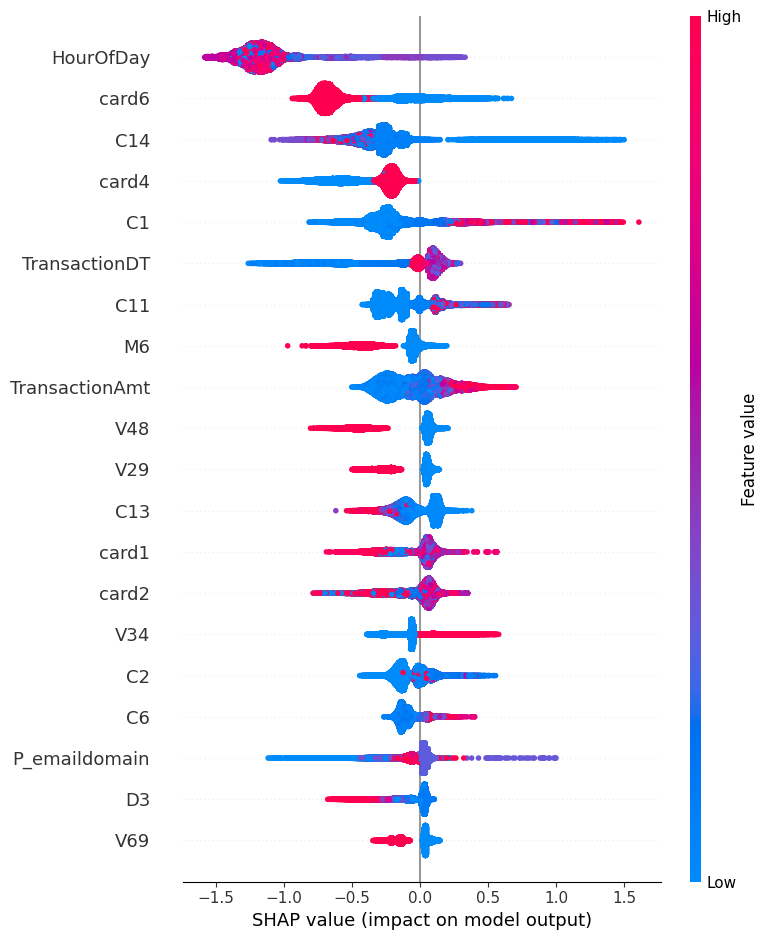

In [29]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=20,
    show=False
)

plt.savefig(
    "charts/shap_summary.png",
    bbox_inches="tight"
)

plt.show()

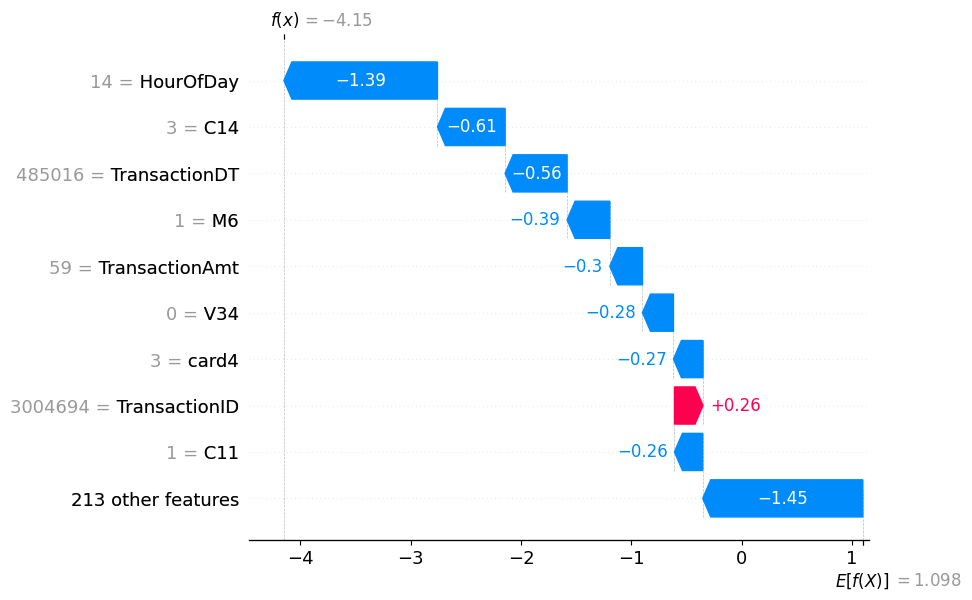

In [32]:
sample_index = 5

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_index]))